   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Dataset1.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fr

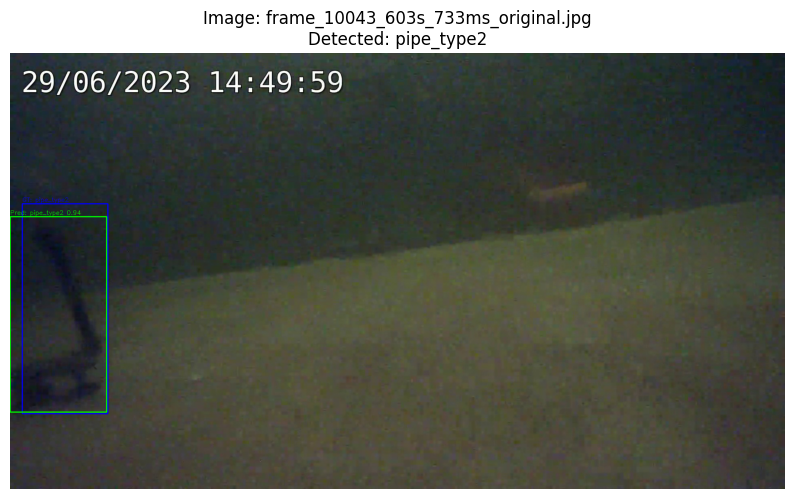

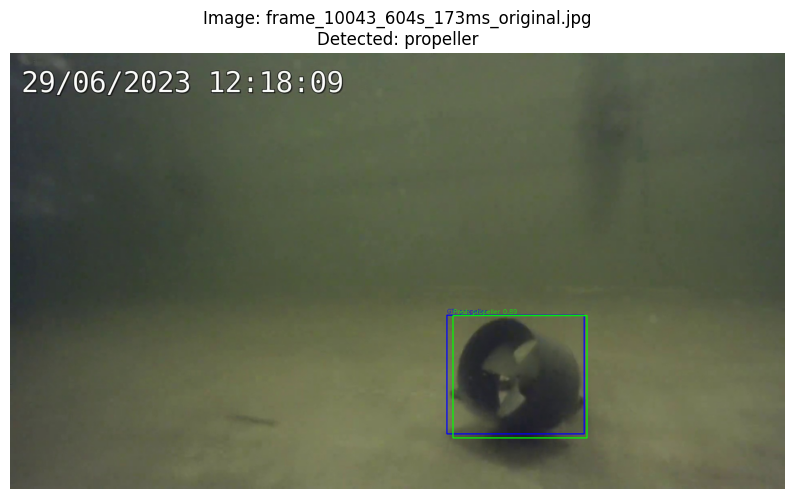

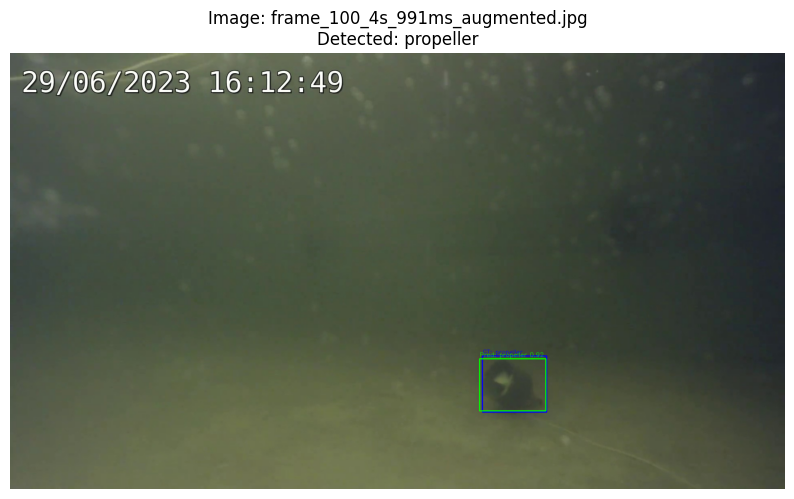

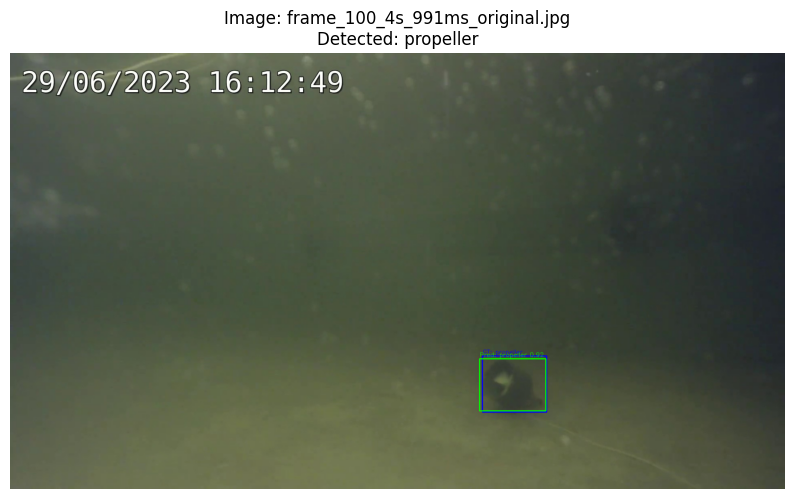

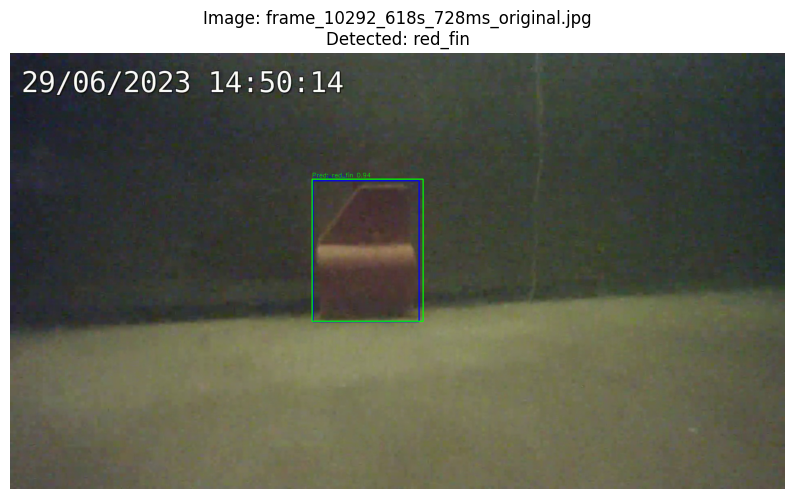

{'model': 'YOLOv10n', 'parameters': 2775520, 'training_time_seconds': 1212.1512179374695, 'avg_inference_time_seconds': 0.010121020131141134, 'total_test_inference_time_seconds': 3.218484401702881, 'fps': 98.80426943556044, 'map50_percent': 96.83579452074792, 'map50_95_percent': 80.99403890971085, 'precision_percent': 94.6341463414634, 'recall_percent': 89.19540229885058, 'detection_accuracy_percent': 94.6341463414634}


In [1]:
!pip install -q ultralytics opencv-python numpy matplotlib

import os, cv2, glob, json, time, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET_PATH = "/kaggle/input/datasets/mdanzirhossainrafath/dataset1/Dataset1"
TEST_IMG = f"{DATASET_PATH}/test/images"
TEST_LBL = f"{DATASET_PATH}/test/labels"
RESULTS_DIR = "/kaggle/working/yolov10_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASSES = ["propeller", "pipe_type2", "red_fin", "net", "qr_codes", "pipe"]
CONF_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5
VIS_SAMPLES = 5

yaml_text = f"""
path: {DATASET_PATH}
train: train/images
val: valid/images
test: test/images

nc: 6
names:
  - propeller
  - pipe_type2
  - red_fin
  - net
  - qr_codes
  - pipe
""".strip()

with open("/kaggle/working/Dataset1.yaml", "w") as f:
    f.write(yaml_text)

def list_images(folder):
    return sorted(glob.glob(os.path.join(folder, "*.jpg")) +
                  glob.glob(os.path.join(folder, "*.jpeg")) +
                  glob.glob(os.path.join(folder, "*.png")))

def read_yolo_labels(txt_file, W, H):
    boxes, labels = [], []
    if not os.path.exists(txt_file):
        return boxes, labels
    with open(txt_file, "r") as f:
        for line in f:
            c, x, y, w, h = line.strip().split()
            c = int(float(c))
            x, y, w, h = map(float, [x, y, w, h])
            boxes.append([(x-w/2)*W, (y-h/2)*H, (x+w/2)*W, (y+h/2)*H])
            labels.append(c)
    return boxes, labels

def iou_xyxy(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = max(0, a[2]-a[0]) * max(0, a[3]-a[1])
    areaB = max(0, b[2]-b[0]) * max(0, b[3]-b[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

MODEL_NAME = "YOLOv10n"
model = YOLO("yolov10n.pt")
device_id = 0 if torch.cuda.is_available() else "cpu"
param_count = sum(p.numel() for p in model.model.parameters())

train_start = time.time()
model.train(data="/kaggle/working/Dataset1.yaml", epochs=30, imgsz=640, batch=16,
            device=device_id, project=RESULTS_DIR, name="train", exist_ok=True)
train_end = time.time()
training_seconds = train_end - train_start

metrics = model.val(data="/kaggle/working/Dataset1.yaml", split="test",
                    project=RESULTS_DIR, name="val", exist_ok=True)

test_images = list_images(TEST_IMG)
times = []
TP = FP = FN = correct = total_preds = 0

for img_path in test_images:
    img = cv2.imread(img_path)
    H, W, _ = img.shape
    start = time.time()
    preds = model(img, verbose=False)[0]
    end = time.time()
    times.append(end - start)

    label_path = os.path.join(TEST_LBL, os.path.splitext(os.path.basename(img_path))[0] + ".txt")
    gt_boxes, gt_labels = read_yolo_labels(label_path, W, H)
    gt = list(zip(gt_boxes, gt_labels))
    matched_gt = set()

    for box, cls, conf in zip(preds.boxes.xyxy, preds.boxes.cls, preds.boxes.conf):
        if float(conf) < CONF_THRESHOLD:
            continue
        pb = box.cpu().numpy().tolist()
        pl = int(cls.cpu().item())
        total_preds += 1
        best_iou, best_idx = 0.0, -1
        for j, (gb, gl) in enumerate(gt):
            if j in matched_gt or pl != gl:
                continue
            iou = iou_xyxy(pb, gb)
            if iou > best_iou:
                best_iou, best_idx = iou, j
        if best_iou >= IOU_THRESHOLD and best_idx != -1:
            TP += 1
            correct += 1
            matched_gt.add(best_idx)
        else:
            FP += 1
    FN += len(gt) - len(matched_gt)

precision = (TP / (TP + FP) * 100) if (TP + FP) > 0 else 0.0
recall = (TP / (TP + FN) * 100) if (TP + FN) > 0 else 0.0
detection_accuracy = (correct / total_preds * 100) if total_preds > 0 else 0.0
avg_inference_time = float(np.mean(times)) if times else 0.0
total_inference_time = float(np.sum(times)) if times else 0.0
fps = (len(test_images) / total_inference_time) if total_inference_time > 0 else 0.0

for img_path in test_images[:VIS_SAMPLES]:
    img = cv2.imread(img_path)
    H, W, _ = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    label_path = os.path.join(TEST_LBL, os.path.splitext(os.path.basename(img_path))[0] + ".txt")
    gt_boxes, gt_labels = read_yolo_labels(label_path, W, H)
    for b, lbl in zip(gt_boxes, gt_labels):
        x1, y1, x2, y2 = map(int, b)
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0,0,255), 2)
        cv2.putText(img_rgb, f"GT: {CLASSES[lbl]}", (x1, max(20, y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

    detected_names = []
    pred = model(img, verbose=False)[0]
    for box, cls, conf in zip(pred.boxes.xyxy, pred.boxes.cls, pred.boxes.conf):
        if float(conf) < CONF_THRESHOLD:
            continue
        x1, y1, x2, y2 = map(int, box.cpu().numpy().tolist())
        class_name = CLASSES[int(cls.cpu().item())]
        detected_names.append(class_name)
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(img_rgb, f"Pred: {class_name} {float(conf):.2f}", (x1, max(40, y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    plt.figure(figsize=(10,10))
    plt.imshow(img_rgb)
    plt.title(f"Image: {os.path.basename(img_path)}\nDetected: {', '.join(sorted(set(detected_names))) if detected_names else 'No object detected'}")
    plt.axis("off")
    plt.show()

summary = {
    "model": "YOLOv10n",
    "parameters": int(param_count),
    "training_time_seconds": float(training_seconds),
    "avg_inference_time_seconds": avg_inference_time,
    "total_test_inference_time_seconds": total_inference_time,
    "fps": fps,
    "map50_percent": float(metrics.box.map50 * 100),
    "map50_95_percent": float(metrics.box.map * 100),
    "precision_percent": float(precision),
    "recall_percent": float(recall),
    "detection_accuracy_percent": float(detection_accuracy)
}

with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(summary)

In [2]:
print(
    f"Model: YOLOv10n\n"
    f"Parameters: {int(param_count)}\n"
    f"Training Time (seconds): {float(training_seconds)}\n"
    f"Average Inference Time (seconds): {avg_inference_time}\n"
    f"Total Test Inference Time (seconds): {total_inference_time}\n"
    f"FPS: {fps}\n"
    f"mAP@0.5 (%): {float(metrics.box.map50 * 100)}\n"
    f"mAP@0.5:0.95 (%): {float(metrics.box.map * 100)}\n"
    f"Precision (%): {float(precision)}\n"
    f"Recall (%): {float(recall)}\n"
    f"Detection Accuracy (%): {float(detection_accuracy)}"
)

Model: YOLOv10n
Parameters: 2775520
Training Time (seconds): 1212.1512179374695
Average Inference Time (seconds): 0.010121020131141134
Total Test Inference Time (seconds): 3.218484401702881
FPS: 98.80426943556044
mAP@0.5 (%): 96.83579452074792
mAP@0.5:0.95 (%): 80.99403890971085
Precision (%): 94.6341463414634
Recall (%): 89.19540229885058
Detection Accuracy (%): 94.6341463414634
